<div align="center">

<h1> <b> MODELO DE RELAJACIÓN SUPERFICIAL ACTIVADA TÉRMICAMENTE PARA EL CRECIMIENTO DE PELÍCULAS DELGADAS </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y objetivos

Este proyecto estudia qué procesos físicos determinan la morfología de una película delgada de cobre (Cu) depositada sobre vidrio por evaporación térmica en una cámara de vacío. Los mecanismos físicos se incorporan uno a uno en cuadernos independientes, de modo que el efecto de cada uno sobre la morfología pueda distinguirse.

El cuaderno 1 de la serie trató la deposición aleatoria (RD), gobernada por la estadística de Poisson, y el cuaderno 2 la deposición aleatoria con relajación superficial (RDSR), en la que la partícula se incorpora siempre a la celda más baja de su vecindad. Ambos modelos omiten una variable central en una cámara de evaporación: la **temperatura del sustrato** ($T$).

Este tercer cuaderno implementa un modelo de **relajación superficial activada térmicamente**. La movilidad del adátomo deja de ser una regla fija e instantánea y pasa a depender de $T$ a través de una probabilidad efectiva de salto. Así se puede estudiar cómo el calentamiento o el enfriamiento del sustrato modifica la rugosidad y la distribución de alturas de la película.

### Objetivos

* Implementar un algoritmo estocástico de caminata aleatoria superficial cuya probabilidad de salto dependa de la temperatura del sustrato.
* Evaluar, con múltiples réplicas estadísticas, la influencia de la temperatura (de 250 K a 700 K) sobre la rugosidad RMS y sobre las alturas extremas de la película.
* Comparar las firmas morfológicas (mapas de alturas, histogramas, perfiles unidimensionales y evolución temporal) a distintas temperaturas, tomando el modelo RD como referencia analítica.

## 2. Marco teórico y modelo físico

### 2.1 Difusión activada y probabilidad efectiva de salto

Sobre una superficie cristalina, un adátomo se mueve en un paisaje de energía periódico y, para saltar a un sitio vecino, debe superar una barrera de energía $E_a$ (Venables, 2000). La tasa de saltos térmicos suele describirse con una ley de tipo Arrhenius (Arrhenius, 1889):

$$\nu = \nu_0 \exp\left(-\frac{E_a}{k_B T}\right),$$

donde $\nu_0$ es la frecuencia de intento y $k_B$ la constante de Boltzmann.

Este cuaderno no implementa la ley de Arrhenius ni utiliza una energía de activación del cobre. Para capturar el efecto cualitativo de la temperatura sin simular las escalas de tiempo microscópicas, se adopta una **probabilidad efectiva** de que el adátomo realice un salto en cada paso de su caminata:

$$P(T) = \frac{T}{T + T_0}.$$

Aquí $T$ es la temperatura absoluta del sustrato y $T_0 = 300\ \mathrm{K}$ es una temperatura de escala, sin calibrar con datos del cobre, para la cual $P(T_0) = 1/2$. La forma funcional de $P(T)$ se eligió por su comportamiento cualitativo y no se deriva de $\nu(T)$. La función crece de forma monótona: $P \to 0$ cuando $T \to 0$, límite en el que el modelo se reduce a RD, y $P \to 1$ cuando $T \to \infty$.

### 2.2 Reglas de la caminata aleatoria térmica

Se usa la misma malla de $N_x \times N_y$ celdas de los cuadernos anteriores, con alturas enteras $h(i, j)$ que cuentan capas efectivas. Cada evento de Monte Carlo sigue estos pasos:

1. Una partícula incide en una celda $(i, j)$ elegida con probabilidad uniforme $1/(N_x N_y)$.
2. En cada paso de la caminata, la partícula intenta saltar con probabilidad $P(T)$. Si el intento falla, se deposita en su celda actual.
3. Si el intento tiene éxito, se consideran los cuatro vecinos de von Neumann (arriba, abajo, izquierda y derecha) que existan en la malla. Un vecino es accesible si su altura cumple $h_{\mathrm{vecino}} \leq h_{\mathrm{actual}} + 1$: la partícula puede descender cualquier desnivel, pero solo puede ascender una capa por salto. Si ningún vecino es accesible, se deposita en su celda actual.
4. La partícula elige con igual probabilidad uno de los vecinos accesibles. Si ese vecino ya fue visitado en la caminata actual, la partícula no se mueve y se deposita en su celda actual, lo que evita retrocesos y bucles. En caso contrario, se desplaza a él.
5. Los pasos 2 a 4 se repiten hasta un máximo de `MAX_DIFFUSION_STEPS` = 20 saltos. Al terminar, la celda final $(i^*, j^*)$ recibe la partícula: $h(i^*, j^*) \leftarrow h(i^*, j^*) + 1$.

Las fronteras son abiertas: los vecinos fuera de la malla no existen. Cada partícula añade exactamente una capa al total, se relocalice o no.

Como el intento térmico se repite en cada paso, sin las reglas de bloqueo el número de saltos de una partícula sigue una distribución geométrica de media $P/(1-P) = T/T_0$, es decir, 0.8 saltos a 250 K y 2.3 saltos a 700 K. La probabilidad de alcanzar el máximo de 20 saltos es $P^{20}$, que vale $8 \times 10^{-4}$ a 700 K, de modo que ese límite es una salvaguarda numérica que apenas interviene en el intervalo simulado. Las reglas de bloqueo (ningún vecino accesible o vecino ya visitado) reducen todavía más el número medio de saltos.

### 2.3 Referencias analíticas

Sea $M = N_x N_y$ el número de celdas y $N$ el número de eventos.

#### Espesor medio

Cada evento añade una capa a la malla, de modo que $\sum h = N$ y $\overline{h}_{\mathrm{teo}} = N/M$. La relación es exacta y expresa la conservación del número de partículas.

#### Límite T = 0 K

Con $T = 0$ se cumple $P = 0$ y ninguna partícula salta, de modo que el modelo coincide con RD. Las alturas siguen entonces una distribución de Poisson de media $\lambda = \overline{h}$, la rugosidad vale $W_{\mathrm{RD}} = \sqrt{\overline{h}}$ y una realización fluctúa alrededor de ese valor con desviación típica $\sigma_W \approx W_{\mathrm{RD}}/\sqrt{2M}$ (cuaderno 1; Barabási & Stanley, 1995, cap. 4). Este límite permite validar el código.

#### Temperaturas mayores que cero

Para $T > 0$ no se usa una predicción analítica de $W$. La validación se apoya en la conservación de partículas, en el límite $T = 0$ y en la comparación con la referencia RD.

## 3. Librerías y configuración

El cálculo numérico usa NumPy (Harris et al., 2020) y la tabla de resultados se organiza con pandas (McKinney, 2010). Los ciclos de difusión y de cálculo de métricas se compilan con Numba (Lam et al., 2015) cuando la librería está instalada; si no lo está, las mismas funciones se ejecutan como Python puro, con más lentitud pero con las mismas propiedades estadísticas. SciPy (Virtanen et al., 2020) aporta la distribución de Poisson de referencia y Matplotlib (Hunter, 2007) se encarga de la visualización.

Numba mantiene un generador de números pseudoaleatorios propio, con un estado independiente del de NumPy: sembrar uno no modifica al otro (Numba, s. f.). Por ello cada simulación fija su semilla dentro de la función compilada (sección 5). Las semillas de las distintas réplicas se derivan de una única semilla con `SeedSequence` de NumPy, de modo que cada réplica es independiente y reproducible por separado. Las secuencias de Numba y de NumPy no tienen por qué coincidir para una misma semilla, de manera que una realización concreta solo es reproducible dentro de un mismo modo de ejecución.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import poisson

# Numba es una dependencia opcional de aceleración. Si no está instalada, las
# funciones numéricas se ejecutan sin compilar: el resultado es estadísticamente
# equivalente, aunque más lento.
try:
    from numba import njit
    NUMBA_DISPONIBLE = True
except ImportError:
    NUMBA_DISPONIBLE = False

    def njit(*args, **kwargs):
        """ Sustituto de ``numba.njit`` que deja la función sin compilar.

        Admite tanto la forma ``@njit`` como la forma ``@njit(...)``.
        """
        if len(args) == 1 and callable(args[0]) and not kwargs:
            return args[0]

        def decorador(funcion):
            return funcion

        return decorador

if not NUMBA_DISPONIBLE:
    print("Numba no está disponible: la simulación se ejecutará en Python puro (más lenta).")

# Mostrar todas las columnas de la tabla de resultados
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Estilo de las figuras. La resolución de guardado (300 dpi) es la adecuada
# para insertarlas en un informe.
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120,
    'savefig.dpi': 300
})

## 4. Parámetros del sistema

Las dimensiones de la malla se dan en celdas, el número de eventos en partículas depositadas, las temperaturas en kelvin y las alturas en capas. Con 100 000 eventos sobre $200 \times 200$ celdas, el espesor medio es de 2.5 capas. Los cuadernos 1 y 2 depositaron 10 capas, así que la comparación con RD se hace aquí con la referencia analítica evaluada a este mismo espesor.

In [2]:
# Configuración geométrica del sustrato (número de celdas en cada dirección)
NX = 200
NY = 200

# Parámetros estocásticos de Monte Carlo
N_EVENTOS = 100_000       # partículas por simulación (espesor medio N_EVENTOS / (NX * NY) = 2.5 capas)
N_REPLICAS = 10           # réplicas independientes por cada temperatura
GUARDAR_CADA = 2_000      # intervalo de muestreo de la evolución temporal, en eventos

# Temperaturas del sustrato que se evalúan (en kelvin)
TEMPERATURES = [250, 300, 350, 400, 500, 600, 700]

# Parámetros del modelo de movilidad
T0 = 300                  # temperatura de escala de P(T) = T / (T + T0), en kelvin
MAX_DIFFUSION_STEPS = 20  # límite numérico de saltos por partícula; con P <= 0.7 se alcanza con probabilidad P**20 <= 8e-4

# Temperatura de la simulación con historial temporal y temperaturas cuyas
# superficies se comparan visualmente (deben pertenecer a TEMPERATURES)
TEMP_REF = 400
TEMPS_MORFOLOGIA = (250, 400, 700)

# Tiempo mínimo, en capas depositadas, desde el que se estima el exponente de
# crecimiento efectivo de la simulación con historial. Se excluye el transitorio
# inicial, en el que la superficie es casi plana.
T_MIN_AJUSTE = 1.0

# Semilla única de la que se derivan las semillas de todas las simulaciones (ver sección 3)
SEMILLA = 42

if not set(TEMPS_MORFOLOGIA) <= set(TEMPERATURES):
    raise ValueError("TEMPS_MORFOLOGIA debe ser un subconjunto de TEMPERATURES.")

## 5. Funciones del modelo

La función `calcular_metricas_numba` obtiene $\overline{h}$ y $W$ con dos recorridos de la malla: primero la media y después las desviaciones respecto a ella. Este esquema evita la cancelación numérica que aparece al restar $\langle h^2 \rangle - \langle h \rangle^2$ cuando la media es grande frente a la dispersión.

La función `difundir_particula_termica` simula la caminata de un adátomo desde su celda de impacto y devuelve la celda donde se deposita. Para elegir el vecino recorre la vecindad dos veces, primero para contar los vecinos accesibles y luego para localizar el elegido, en lugar de construir un arreglo de candidatos en cada salto.

La función `ejecutar_simulacion_termica_con_historial` implementa el ciclo Monte Carlo y registra las métricas cada `guardar_cada` eventos; `ejecutar_simulacion_termica` la invoca sin conservar el historial. El ciclo es estrictamente secuencial: cada partícula se mueve sobre el estado que dejaron las anteriores y todas modifican la misma matriz de alturas, por lo que una simulación no se paraleliza. Las réplicas de la sección 6 son independientes entre sí y se ejecutan en serie.

In [3]:
@njit
def calcular_metricas_numba(superficie, nx, ny):
    """Calcula el espesor medio y la rugosidad RMS de una superficie.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Altura de cada celda, en capas.
    nx, ny : int
        Número de celdas en cada dirección.

    Devuelve
    --------
    espesor : float
        Altura media, en capas.
    rugosidad : float
        Desviación estándar poblacional de las alturas (divisor nx * ny), en capas.
    """
    # Se calcula primero la media y después las desviaciones respecto a ella
    # (dos pasadas). Restar <h^2> - <h>^2 en una sola pasada perdería precisión
    # cuando la media es grande frente a la dispersión.
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)

    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diferencia = superficie[i, j] - espesor
            suma_varianza += diferencia * diferencia
    rugosidad = np.sqrt(suma_varianza / (nx * ny))

    return espesor, rugosidad

In [4]:
@njit
def difundir_particula_termica(superficie, x_init, y_init, nx, ny, temp, t0, max_pasos):
    """Simula la caminata aleatoria activada térmicamente de un adátomo.

    En cada paso la partícula salta con probabilidad P(T) = temp / (temp + t0).
    Solo puede moverse a un vecino de von Neumann cuya altura no supere en más
    de una capa la de su celda actual, y se detiene si el vecino elegido ya fue
    visitado en esta caminata. Las fronteras son abiertas.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Alturas actuales, en capas. La función no las modifica.
    x_init, y_init : int
        Índices de la celda de impacto.
    nx, ny : int
        Número de celdas en cada dirección.
    temp : float
        Temperatura del sustrato, en kelvin.
    t0 : float
        Temperatura de escala de la probabilidad efectiva, en kelvin.
    max_pasos : int
        Número máximo de saltos de la caminata.

    Devuelve
    --------
    curr_x, curr_y : int
        Índices de la celda que recibe la partícula.
    """
    curr_x = x_init
    curr_y = y_init

    # Historial de celdas visitadas en esta caminata (arreglos de tamaño fijo,
    # compatibles con la compilación).
    visitados_x = np.empty(max_pasos + 1, dtype=np.int32)
    visitados_y = np.empty(max_pasos + 1, dtype=np.int32)
    visitados_x[0] = curr_x
    visitados_y[0] = curr_y
    conteo_visitados = 1

    # Desplazamientos de von Neumann: izquierda, derecha, abajo, arriba
    dx = (-1, 1, 0, 0)
    dy = (0, 0, -1, 1)

    # Probabilidad efectiva de saltar en cada paso
    p_difusion = temp / (temp + t0)

    for _ in range(max_pasos):
        # Intento térmico: si falla, la partícula se deposita en su celda actual.
        if np.random.random() >= p_difusion:
            break

        # Altura máxima de un vecino accesible: como mucho una capa por encima.
        h_limite = superficie[curr_x, curr_y] + 1

        # Primer recorrido: número de vecinos accesibles.
        conteo_validos = 0
        for i in range(4):
            nx_c = curr_x + dx[i]
            ny_c = curr_y + dy[i]
            if 0 <= nx_c < nx and 0 <= ny_c < ny:
                if superficie[nx_c, ny_c] <= h_limite:
                    conteo_validos += 1

        # Sin posiciones accesibles, el adátomo se detiene.
        if conteo_validos == 0:
            break

        # Selección equiprobable del vecino. Un segundo recorrido localiza al
        # elegido sin crear arreglos temporales en cada salto.
        idx_elegido = np.random.randint(0, conteo_validos)
        next_x = curr_x
        next_y = curr_y
        contador = 0
        for i in range(4):
            nx_c = curr_x + dx[i]
            ny_c = curr_y + dy[i]
            if 0 <= nx_c < nx and 0 <= ny_c < ny:
                if superficie[nx_c, ny_c] <= h_limite:
                    if contador == idx_elegido:
                        next_x = nx_c
                        next_y = ny_c
                        break
                    contador += 1

        # Control de lazo: si el sitio ya fue pisado en esta caminata, la partícula se detiene.
        ya_visitado = False
        for v in range(conteo_visitados):
            if visitados_x[v] == next_x and visitados_y[v] == next_y:
                ya_visitado = True
                break

        if ya_visitado:
            break

        # Salto efectivo
        curr_x = next_x
        curr_y = next_y
        visitados_x[conteo_visitados] = curr_x
        visitados_y[conteo_visitados] = curr_y
        conteo_visitados += 1

    return curr_x, curr_y

In [5]:
@njit
def ejecutar_simulacion_termica_con_historial(nx, ny, n_eventos, temp, t0, max_pasos, guardar_cada, semilla):
    """Ejecuta la simulación a una temperatura dada y registra la evolución temporal.

    Cada evento lanza una partícula sobre una celda elegida con probabilidad
    uniforme y la deposita donde termina su caminata térmica
    (ver ``difundir_particula_termica``).

    Parámetros
    ----------
    nx, ny : int
        Número de celdas en cada dirección.
    n_eventos : int
        Número total de eventos, igual al número de partículas depositadas.
    temp : float
        Temperatura del sustrato, en kelvin.
    t0 : float
        Temperatura de escala de la probabilidad efectiva, en kelvin.
    max_pasos : int
        Número máximo de saltos por partícula.
    guardar_cada : int
        Intervalo de muestreo, en eventos, de las métricas temporales.
    semilla : int
        Semilla del generador pseudoaleatorio.

    Devuelve
    --------
    superficie : ndarray int32, forma (nx, ny)
        Alturas finales, en capas.
    hist_eventos : ndarray int32
        Número de eventos transcurridos en cada muestreo.
    hist_espesor, hist_rugosidad : ndarray float64
        Espesor medio y rugosidad RMS, en capas, en cada muestreo.
    """
    if nx <= 0 or ny <= 0:
        raise ValueError("nx y ny deben ser positivos.")
    if guardar_cada <= 0 or guardar_cada > n_eventos:
        raise ValueError("Se requiere 0 < guardar_cada <= n_eventos.")
    if temp < 0 or t0 <= 0 or max_pasos < 0:
        raise ValueError("Se requiere temp >= 0, t0 > 0 y max_pasos >= 0.")

    # En Numba, np.random.seed solo actúa sobre el generador de Numba si se
    # llama dentro de una función compilada; por eso la semilla se fija aquí.
    np.random.seed(semilla)

    superficie = np.zeros((nx, ny), dtype=np.int32)

    # Arreglos de tamaño fijo para el historial: evitan crecer listas dentro
    # del ciclo compilado.
    tamano_hist = n_eventos // guardar_cada
    hist_eventos = np.zeros(tamano_hist, dtype=np.int32)
    hist_espesor = np.zeros(tamano_hist, dtype=np.float64)
    hist_rugosidad = np.zeros(tamano_hist, dtype=np.float64)

    idx_hist = 0
    for evento in range(1, n_eventos + 1):
        # Celda de impacto, equiprobable e independiente de la altura actual.
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)

        # Caminata térmica. Depende del estado actual de la superficie, por lo
        # que los eventos deben procesarse en orden.
        x_f, y_f = difundir_particula_termica(superficie, x_i, y_i, nx, ny, temp, t0, max_pasos)
        superficie[x_f, y_f] += 1

        # Las métricas se evalúan sobre el estado acumulado de la superficie.
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_numba(superficie, nx, ny)
            hist_eventos[idx_hist] = evento
            hist_espesor[idx_hist] = esp
            hist_rugosidad[idx_hist] = rug
            idx_hist += 1

    return superficie, hist_eventos, hist_espesor, hist_rugosidad


@njit
def ejecutar_simulacion_termica(nx, ny, n_eventos, temp, t0, max_pasos, semilla):
    """Ejecuta la simulación a una temperatura dada y devuelve solo la superficie final.

    Equivale a ``ejecutar_simulacion_termica_con_historial`` con una única
    muestra temporal al final; los parámetros son los mismos, salvo ``guardar_cada``.
    """
    superficie, _, _, _ = ejecutar_simulacion_termica_con_historial(
        nx, ny, n_eventos, temp, t0, max_pasos, n_eventos, semilla
    )
    return superficie

## 6. Ejecución del experimento multitemperatura y validación

Se simulan `N_REPLICAS` réplicas independientes para cada temperatura, cada una con su propia semilla derivada de `SEMILLA`. En cada simulación se verifica que $\sum h = N$. Antes de interpretar el barrido se valida el límite $T = 0$ K, en el que el modelo debe reducirse a RD: la rugosidad media de las réplicas se compara con $W_{\mathrm{RD}} = \sqrt{\overline{h}}$ mediante la variable

$$z = \frac{\overline{W}_{\mathrm{sim}} - W_{\mathrm{RD}}}{\sigma_W/\sqrt{N_{\mathrm{réplicas}}}},$$

y se considera compatible cuando $|z| \leq 3$. La sección incluye además una simulación con historial temporal a `TEMP_REF`, cuyo exponente de crecimiento efectivo $\beta_{\mathrm{ef}}$ es la pendiente de $\ln W$ frente a $\ln t$ para $t \geq$ `T_MIN_AJUSTE` (en RD vale $1/2$).

In [6]:
n_celdas = NX * NY
espesor_teo = N_EVENTOS / n_celdas
rugosidad_rd = np.sqrt(espesor_teo)                                # RD: W = sqrt(h)
celdas_vacias_rd = 100 * poisson.pmf(0, espesor_teo)               # % de celdas con h = 0 esperado en RD

# Semillas independientes y reproducibles derivadas de SEMILLA: la secuencia 0 se
# reserva para el límite T = 0 K y las demás corresponden a cada temperatura.
secuencias = np.random.SeedSequence(SEMILLA).spawn(len(TEMPERATURES) + 1)
semillas_limite = secuencias[0].generate_state(N_REPLICAS)
semillas_temp = [secuencia.generate_state(N_REPLICAS) for secuencia in secuencias[1:]]


def simular_replicas(temp, semillas):
    """Ejecuta una réplica por semilla a la temperatura ``temp`` y resume sus métricas finales.

    Devuelve un diccionario con un arreglo por magnitud (una entrada por réplica)
    y la superficie final de la primera réplica.
    """
    n = len(semillas)
    res = {clave: np.zeros(n) for clave in ("espesor", "rugosidad", "maximo", "minimo", "vacias")}
    for r, semilla in enumerate(semillas):
        superficie = ejecutar_simulacion_termica(
            NX, NY, N_EVENTOS, temp, T0, MAX_DIFFUSION_STEPS, int(semilla)
        )
        # Cada evento añade exactamente una capa, aunque la partícula se relocalice: si
        # la suma no coincide con N_EVENTOS, el resultado es incorrecto aunque no se
        # lance ninguna excepción.
        if superficie.sum() != N_EVENTOS:
            raise RuntimeError(f"La suma de alturas no coincide con N_EVENTOS (T = {temp} K, réplica {r}).")
        res["espesor"][r] = np.mean(superficie)
        res["rugosidad"][r] = np.std(superficie)
        res["maximo"][r] = np.max(superficie)
        res["minimo"][r] = np.min(superficie)
        res["vacias"][r] = 100 * np.mean(superficie == 0)
        if r == 0:
            res["primera"] = superficie
    return res


# Límite T = 0 K (sin saltos): el modelo debe reducirse a RD.
print("Simulando el límite T = 0 K (referencia RD)...")
limite = simular_replicas(0, semillas_limite)

# Barrido de temperaturas
lista_resultados = []
superficies_muestra = {}    # superficie de la primera réplica para la comparación visual

for temp, semillas in zip(TEMPERATURES, semillas_temp):
    print(f"Simulando T = {temp} K...")
    res = simular_replicas(temp, semillas)
    if temp in TEMPS_MORFOLOGIA:
        superficies_muestra[temp] = res["primera"]

    # Desviaciones estándar muestrales (ddof = 1) entre réplicas
    lista_resultados.append({
        "Temperatura (K)": temp,
        "P(T)": temp / (temp + T0),
        "Espesor medio (capas)": res["espesor"].mean(),
        "Rugosidad media (capas)": res["rugosidad"].mean(),
        "Desv. rugosidad": res["rugosidad"].std(ddof=1),
        "W / W_RD": res["rugosidad"].mean() / rugosidad_rd,
        "Altura máxima media": res["maximo"].mean(),
        "Desv. altura máxima": res["maximo"].std(ddof=1),
        "Altura mínima media": res["minimo"].mean(),
        "Celdas vacías (%)": res["vacias"].mean(),
    })

print("Experimento multitemperatura finalizado.")

Simulando el límite T = 0 K (referencia RD)...
Simulando T = 250 K...
Simulando T = 300 K...
Simulando T = 350 K...
Simulando T = 400 K...
Simulando T = 500 K...
Simulando T = 600 K...
Simulando T = 700 K...
Experimento multitemperatura finalizado.


In [7]:
# Validación del límite T = 0 K frente a la referencia analítica de RD
sigma_rd = rugosidad_rd / np.sqrt(2 * n_celdas)                 # fluctuación de W en una realización
error_estandar = sigma_rd / np.sqrt(N_REPLICAS)                 # fluctuación de la media de las réplicas
z_limite = (limite["rugosidad"].mean() - rugosidad_rd) / error_estandar

ANCHO = 66


def fila(etiqueta, valor):
    print(f"{etiqueta:<35}: {valor}")


print("=" * ANCHO)
print("VALIDACIÓN DEL LÍMITE T = 0 K (MODELO RD)".center(ANCHO))
print("=" * ANCHO)
fila("Réplicas", N_REPLICAS)
fila("Espesor medio simulado", f"{limite['espesor'].mean():.4f} capas")
fila("Espesor medio teórico", f"{espesor_teo:.4f} capas")
fila("Rugosidad RMS simulada (media)", f"{limite['rugosidad'].mean():.4f} capas")
fila("Rugosidad RMS teórica (RD)", f"{rugosidad_rd:.4f} capas")
fila("Fluctuación esperada de la media", f"{error_estandar:.4f} capas")
fila("Desviación z", f"{z_limite:+.2f}")
print("=" * ANCHO)

if abs(z_limite) <= 3:
    print("A T = 0 K la rugosidad es compatible con RD (|z| <= 3).")
else:
    print("A T = 0 K la rugosidad se aparta de RD (|z| > 3): revisar el generador y el algoritmo.")

            VALIDACIÓN DEL LÍMITE T = 0 K (MODELO RD)             
Réplicas                           : 10
Espesor medio simulado             : 2.5000 capas
Espesor medio teórico              : 2.5000 capas
Rugosidad RMS simulada (media)     : 1.5813 capas
Rugosidad RMS teórica (RD)         : 1.5811 capas
Fluctuación esperada de la media   : 0.0018 capas
Desviación z                       : +0.08
A T = 0 K la rugosidad es compatible con RD (|z| <= 3).


In [8]:
df_resultados = pd.DataFrame(lista_resultados)
# Tabla resumen: media y desviación estándar entre réplicas para cada temperatura
df_resultados.round(3)

,Temperatura (K),P(T),Espesor medio (capas),Rugosidad media (capas),Desv. rugosidad,W / W_RD,Altura máxima media,Desv. altura máxima,Altura mínima media,Celdas vacías (%)
0,250,0.455,2.5,1.333,0.005,0.843,9.2,0.422,0.0,5.544
1,300,0.500,2.5,1.308,0.003,0.827,8.9,0.568,0.0,5.239
2,350,0.538,2.5,1.289,0.004,0.815,8.9,0.876,0.0,5.031
3,400,0.571,2.5,1.270,0.003,0.803,8.2,0.422,0.0,4.802
4,500,0.625,2.5,1.238,0.004,0.783,8.3,0.483,0.0,4.382
5,600,0.667,2.5,1.217,0.003,0.769,8.4,0.516,0.0,4.133
6,700,0.700,2.5,1.199,0.003,0.758,8.1,0.738,0.0,3.910


In [9]:
# Simulación con historial temporal a la temperatura de referencia
print(f"Ejecutando la simulación con historial temporal a T = {TEMP_REF} K...")

superficie_ref, hist_ev, hist_esp, hist_rug = ejecutar_simulacion_termica_con_historial(
    NX, NY, N_EVENTOS, TEMP_REF, T0, MAX_DIFFUSION_STEPS, GUARDAR_CADA, SEMILLA
)

print("Simulación con historial completada.")

if superficie_ref.sum() != N_EVENTOS:
    raise RuntimeError("La suma de alturas no coincide con el número de partículas depositadas.")

# Exponente de crecimiento efectivo: pendiente de ln W frente a ln t, con t en capas
# depositadas y excluyendo el transitorio inicial.
t_capas = hist_ev / n_celdas
tramo = t_capas >= T_MIN_AJUSTE
if np.count_nonzero(tramo) >= 3:
    beta_efectivo = np.polyfit(np.log(t_capas[tramo]), np.log(hist_rug[tramo]), 1)[0]
else:
    beta_efectivo = np.nan   # muy pocas muestras en el tramo: el ajuste no es fiable

rug_ref = np.std(superficie_ref)
print("-" * ANCHO)
fila(f"Rugosidad RMS a {TEMP_REF} K", f"{rug_ref:.4f} capas")
fila("Rugosidad RMS de referencia (RD)", f"{rugosidad_rd:.4f} capas")
fila("Cociente W(T) / W(RD)", f"{rug_ref / rugosidad_rd:.3f}")
fila("Exponente de crecimiento efectivo", f"{beta_efectivo:.3f}  (RD: 0.5)")
print("-" * ANCHO)

Ejecutando la simulación con historial temporal a T = 400 K...
Simulación con historial completada.
------------------------------------------------------------------
Rugosidad RMS a 400 K              : 1.2722 capas
Rugosidad RMS de referencia (RD)   : 1.5811 capas
Cociente W(T) / W(RD)              : 0.805
Exponente de crecimiento efectivo  : 0.332  (RD: 0.5)
------------------------------------------------------------------


## 7. Visualización de resultados

Las primeras cuatro figuras resumen el barrido de temperaturas: la rugosidad y la altura máxima frente a la temperatura, la comparación topográfica de tres temperaturas con una escala de color común y las distribuciones de alturas frente a la del modelo RD. Las barras de error indican la desviación estándar entre réplicas y el punto en $T = 0$ K corresponde al límite RD simulado. Las cuatro figuras siguientes muestran las firmas morfológicas de la simulación individual a la temperatura de referencia. Además de mostrarse en el cuaderno, cada figura se guarda como archivo PNG en el directorio de trabajo.

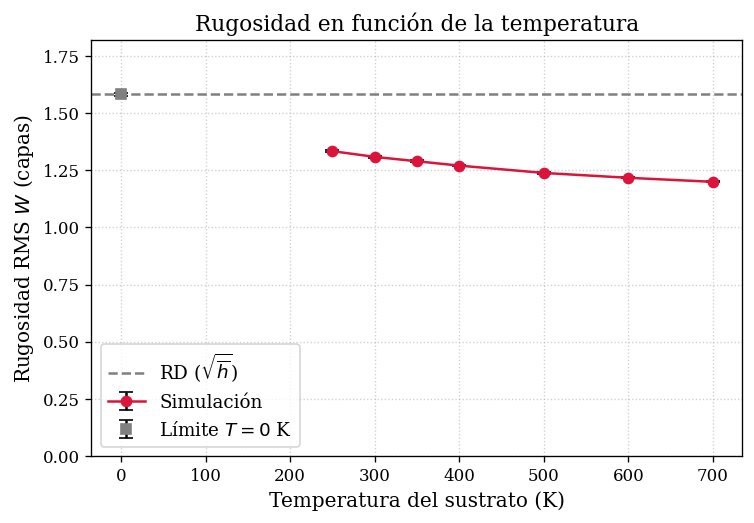

In [10]:
# Rugosidad RMS frente a la temperatura
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    df_resultados["Temperatura (K)"], df_resultados["Rugosidad media (capas)"],
    yerr=df_resultados["Desv. rugosidad"], fmt="o-", color="crimson", ecolor="black",
    capsize=4, lw=1.5, label="Simulación",
)
ax.errorbar(
    0, limite["rugosidad"].mean(), yerr=limite["rugosidad"].std(ddof=1),
    fmt="s", color="gray", ecolor="black", capsize=4, label=r"Límite $T = 0$ K",
)
ax.axhline(rugosidad_rd, color="gray", linestyle="--", label=r"RD ($\sqrt{\overline{h}}$)")
ax.set_xlabel("Temperatura del sustrato (K)")
ax.set_ylabel(r"Rugosidad RMS $W$ (capas)")
ax.set_ylim(0, 1.15 * rugosidad_rd)
ax.set_title("Rugosidad en función de la temperatura")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower left")
fig.savefig("termico_rugosidad_vs_temp.png", bbox_inches="tight")
plt.show()

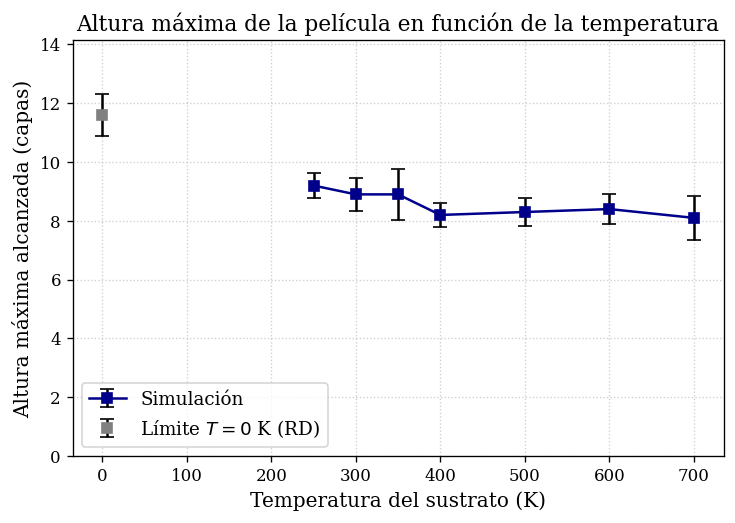

In [11]:
# Altura máxima frente a la temperatura
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    df_resultados["Temperatura (K)"], df_resultados["Altura máxima media"],
    yerr=df_resultados["Desv. altura máxima"], fmt="s-", color="darkblue", ecolor="black",
    capsize=4, lw=1.5, label="Simulación",
)
ax.errorbar(
    0, limite["maximo"].mean(), yerr=limite["maximo"].std(ddof=1),
    fmt="s", color="gray", ecolor="black", capsize=4, label=r"Límite $T = 0$ K (RD)",
)
ax.set_xlabel("Temperatura del sustrato (K)")
ax.set_ylabel("Altura máxima alcanzada (capas)")
# El límite superior se calcula con los datos, para que ninguna barra de error quede recortada.
techo = max(
    (df_resultados["Altura máxima media"] + df_resultados["Desv. altura máxima"]).max(),
    limite["maximo"].mean() + limite["maximo"].std(ddof=1),
)
ax.set_ylim(0, 1.15 * techo)
ax.set_title("Altura máxima de la película en función de la temperatura")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower left")
fig.savefig("termico_alturamax_vs_temp.png", bbox_inches="tight")
plt.show()

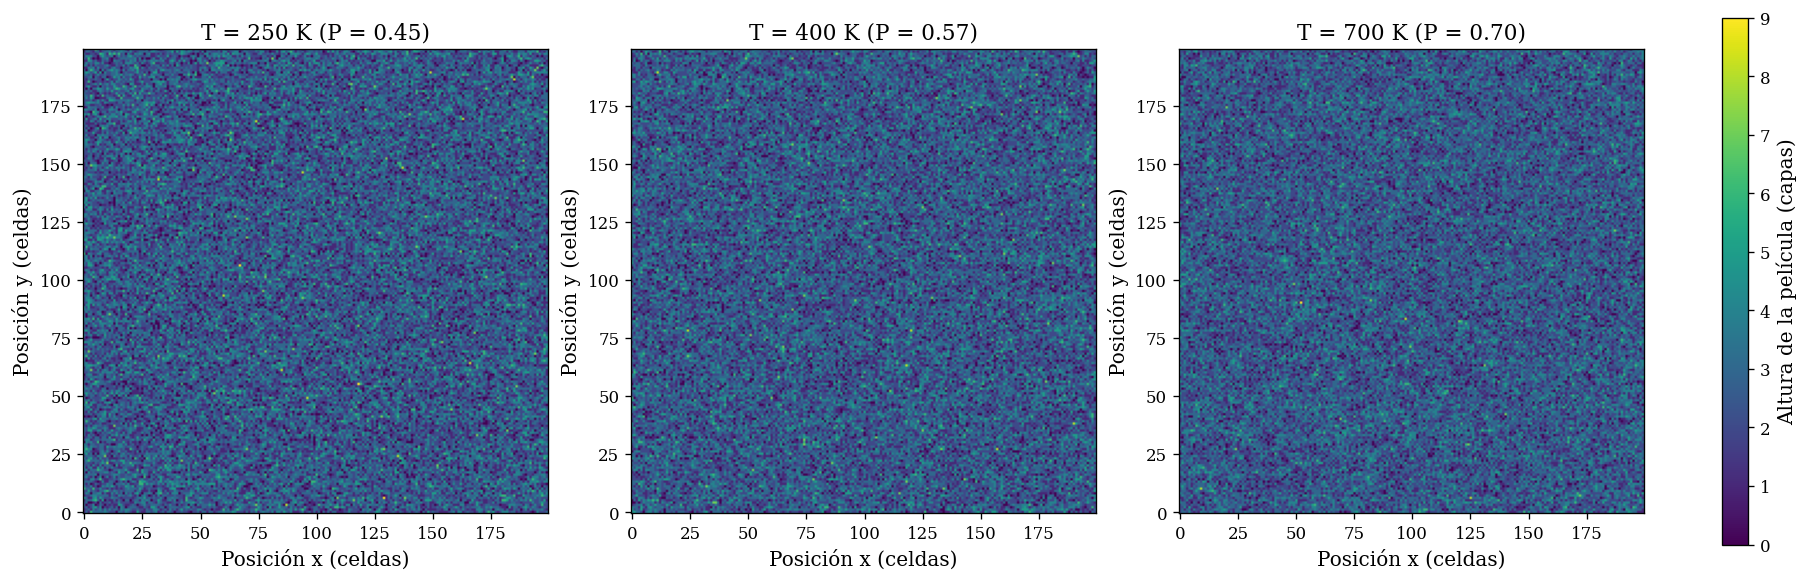

In [12]:
# Comparación topográfica a tres temperaturas, con una escala de color común
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
vmax_comun = max(int(superficies_muestra[temp].max()) for temp in TEMPS_MORFOLOGIA)

for ax, temp in zip(axes, TEMPS_MORFOLOGIA):
    # Se transpone la matriz para que el eje horizontal sea x (primer índice de la
    # malla) y el vertical sea y (segundo índice).
    imagen = ax.imshow(
        superficies_muestra[temp].T, origin="lower", cmap="viridis", vmin=0, vmax=vmax_comun
    )
    ax.set_title(f"T = {temp} K (P = {temp / (temp + T0):.2f})")
    ax.set_xlabel("Posición x (celdas)")
    ax.set_ylabel("Posición y (celdas)")
fig.colorbar(imagen, ax=axes, label="Altura de la película (capas)")
fig.savefig("termico_comparativa_topografica.png", bbox_inches="tight")
plt.show()

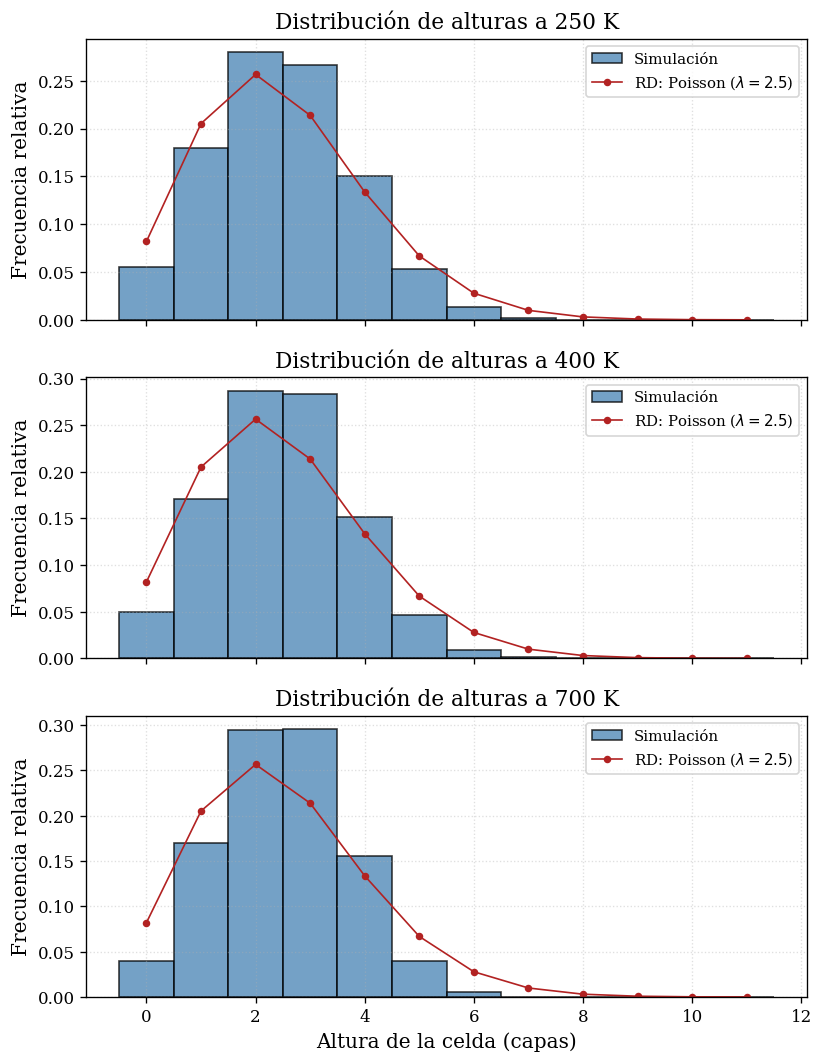

In [13]:
# Distribuciones de alturas a tres temperaturas frente a la estadística de Poisson del modelo RD
altura_sup = max(
    max(int(superficies_muestra[temp].max()) for temp in TEMPS_MORFOLOGIA),
    int(np.ceil(espesor_teo + 5 * rugosidad_rd)),
)
bordes = np.arange(0, altura_sup + 2) - 0.5          # un intervalo de anchura unidad por altura entera
alturas_enteras = np.arange(0, altura_sup + 1)

fig, axes = plt.subplots(len(TEMPS_MORFOLOGIA), 1, figsize=(7, 9), sharex=True)
for ax, temp in zip(axes, TEMPS_MORFOLOGIA):
    # Con density=True e intervalos de anchura unidad, la altura de cada barra es la
    # frecuencia relativa de esa altura.
    ax.hist(
        superficies_muestra[temp].ravel(), bins=bordes, density=True,
        alpha=0.75, color="steelblue", edgecolor="black", label="Simulación",
    )
    ax.plot(
        alturas_enteras, poisson.pmf(alturas_enteras, espesor_teo), "o-",
        color="firebrick", markersize=3.5, linewidth=1.0,
        label=rf"RD: Poisson ($\lambda = {espesor_teo:g}$)",
    )
    ax.set_title(f"Distribución de alturas a {temp} K")
    ax.set_ylabel("Frecuencia relativa")
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("Altura de la celda (capas)")
fig.tight_layout()
fig.savefig("termico_comparativa_histogramas.png", bbox_inches="tight")
plt.show()

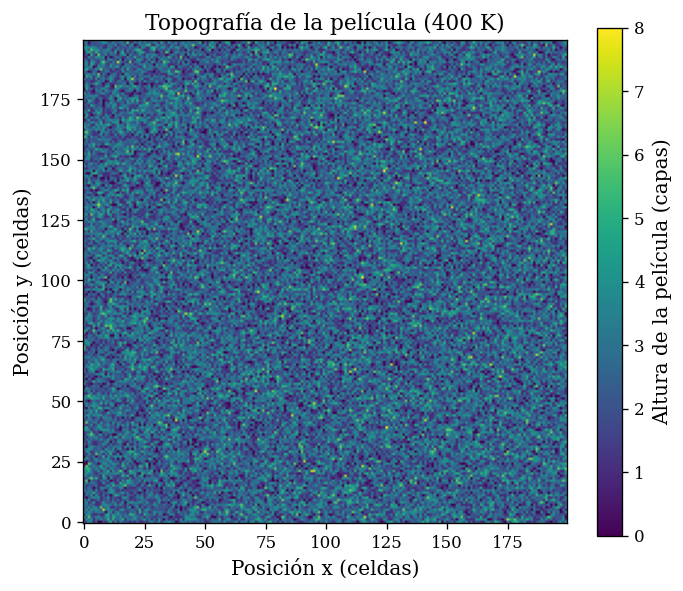

In [14]:
# Topografía de la simulación individual a la temperatura de referencia
fig, ax = plt.subplots(figsize=(6.5, 5.5))
# Se transpone la matriz para que el eje horizontal sea x (primer índice de la malla).
imagen = ax.imshow(superficie_ref.T, origin="lower", cmap="viridis")
fig.colorbar(imagen, ax=ax, label="Altura de la película (capas)")
ax.set_xlabel("Posición x (celdas)")
ax.set_ylabel("Posición y (celdas)")
ax.set_title(f"Topografía de la película ({TEMP_REF} K)")
fig.savefig("ref_topografia_2d.png", bbox_inches="tight")
plt.show()

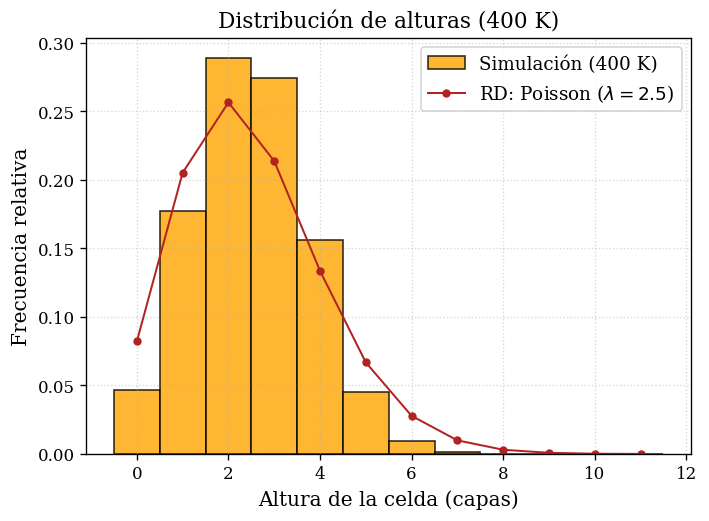

In [15]:
# Histograma de alturas de la simulación individual frente a la estadística de Poisson del modelo RD
altura_sup_ref = max(int(superficie_ref.max()), int(np.ceil(espesor_teo + 5 * rugosidad_rd)))
bordes_ref = np.arange(0, altura_sup_ref + 2) - 0.5
alturas_ref = np.arange(0, altura_sup_ref + 1)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.hist(
    superficie_ref.ravel(), bins=bordes_ref, density=True, edgecolor="black",
    color="orange", alpha=0.8, label=f"Simulación ({TEMP_REF} K)",
)
ax.plot(
    alturas_ref, poisson.pmf(alturas_ref, espesor_teo), "o-", color="firebrick",
    markersize=4, linewidth=1.2, label=rf"RD: Poisson ($\lambda = {espesor_teo:g}$)",
)
ax.set_xlabel("Altura de la celda (capas)")
ax.set_ylabel("Frecuencia relativa")
ax.set_title(f"Distribución de alturas ({TEMP_REF} K)")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()
fig.savefig("ref_histograma.png", bbox_inches="tight")
plt.show()

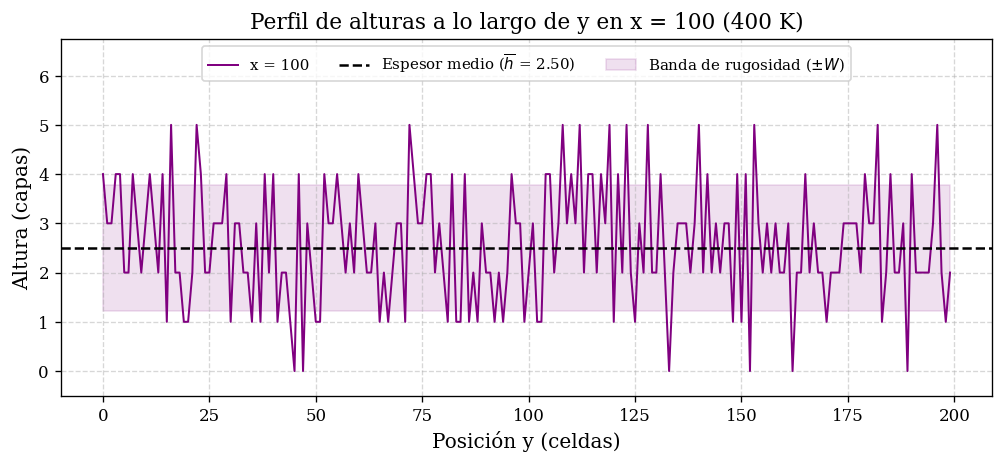

In [16]:
# Perfil unidimensional: alturas a lo largo de y en la coordenada x central
x_central = NX // 2
perfil = superficie_ref[x_central, :]
espesor_ref = np.mean(superficie_ref)

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(perfil, color="purple", linewidth=1.2, label=f"x = {x_central}")
ax.axhline(
    espesor_ref, color="black", linestyle="--",
    label=rf"Espesor medio ($\overline{{h}}$ = {espesor_ref:.2f})",
)
ax.fill_between(
    range(NY), espesor_ref - rug_ref, espesor_ref + rug_ref,
    color="purple", alpha=0.12, label=r"Banda de rugosidad ($\pm W$)",
)
ax.set_title(f"Perfil de alturas a lo largo de y en x = {x_central} ({TEMP_REF} K)")
ax.set_xlabel("Posición y (celdas)")
ax.set_ylabel("Altura (capas)")
ax.grid(True, linestyle="--", alpha=0.5)
# Margen superior para que la leyenda no tape el perfil.
ax.set_ylim(min(perfil.min(), 0) - 0.5, perfil.max() + 0.35 * (perfil.max() - perfil.min()))
ax.legend(loc="upper center", ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig("ref_perfil_unidimensional.png", bbox_inches="tight")
plt.show()

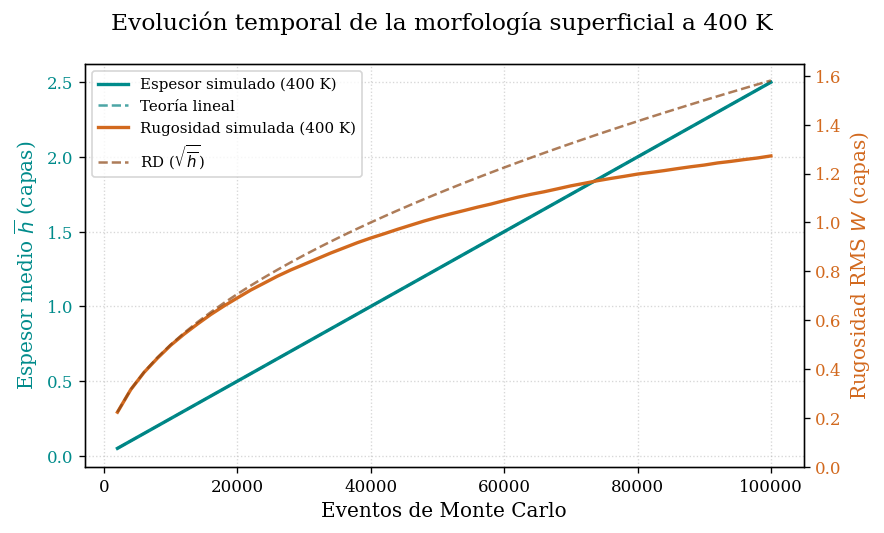

In [17]:
# Evolución temporal conjunta del espesor medio y de la rugosidad
fig, ax1 = plt.subplots(figsize=(7.5, 4.5))

color_esp = "darkcyan"
ax1.set_xlabel("Eventos de Monte Carlo")
ax1.set_ylabel(r"Espesor medio $\overline{h}$ (capas)", color=color_esp)
ax1.plot(hist_ev, hist_esp, label=f"Espesor simulado ({TEMP_REF} K)", color=color_esp, linewidth=2)
ax1.plot(hist_ev, hist_ev / n_celdas, "--", label="Teoría lineal", color="teal", alpha=0.7)
ax1.tick_params(axis="y", labelcolor=color_esp)
ax1.grid(True, linestyle=":", alpha=0.5)

# Segundo eje vertical para la rugosidad, cuya escala numérica es distinta.
ax2 = ax1.twinx()
color_rug = "chocolate"
ax2.set_ylabel(r"Rugosidad RMS $W$ (capas)", color=color_rug)
ax2.plot(hist_ev, hist_rug, label=f"Rugosidad simulada ({TEMP_REF} K)", color=color_rug, linewidth=2)
ax2.plot(
    hist_ev, np.sqrt(hist_ev / n_celdas), "--",
    label=r"RD ($\sqrt{\overline{h}}$)", color="saddlebrown", alpha=0.7,
)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="y", labelcolor=color_rug)

fig.suptitle(f"Evolución temporal de la morfología superficial a {TEMP_REF} K")
fig.tight_layout()

# Una sola leyenda con las curvas de ambos ejes
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left", fontsize=9)
fig.savefig("ref_evolucion_temporal.png", bbox_inches="tight")
plt.show()

## 8. Análisis de resultados

### 8.1 Conservación de partículas y límite $T = 0$ K

El espesor medio simulado coincide con $N/(N_x N_y) = 2.5$ capas en todas las simulaciones. Se trata de una identidad y no de una prueba estadística: cada evento añade exactamente una capa, de modo que la suma de las alturas es $N$ por construcción, y la ejecución lo verifica de forma explícita. En el límite $T = 0$ K no hay saltos y el modelo se reduce a RD. La salida de la sección 6 compara la rugosidad simulada en ese límite con $W_{\mathrm{RD}} = \sqrt{2.5} \approx 1.58$ capas mediante la variable $z$, lo que valida el código frente a una predicción analítica independiente.

### 8.2 Dependencia de la rugosidad con la temperatura

La rugosidad RMS disminuye de forma monótona al aumentar la temperatura, de aproximadamente 1.33 capas a 250 K a 1.20 capas a 700 K, una reducción cercana al 10 %. Todas las temperaturas quedan por debajo de la referencia RD ($\approx 1.58$ capas), pero la rugosidad conserva entre el 76 % y el 84 % de ese valor, como muestra la columna $W/W_{\mathrm{RD}}$ de la tabla. El efecto de la temperatura es, por tanto, moderado y no hay una transición marcada dentro del intervalo simulado.

Esto es coherente con la definición de $P(T)$. Incluso a 250 K la probabilidad de salto ya es $P \approx 0.45$, y a 700 K vale $P = 0.70$. El número medio de saltos sin bloqueos, $T/T_0$, pasa de 0.8 a 2.3, y las reglas de bloqueo lo reducen aún más. La relajación es, por tanto, de muy corto alcance: en promedio, cada partícula da unos pocos saltos. Con un máximo de 20 saltos la partícula podría recorrer distancias mayores, pero esa posibilidad casi no se materializa, ya que la probabilidad de alcanzar el máximo es del orden de $10^{-3}$ o menor.

### 8.3 Alturas extremas y cobertura del sustrato

La altura máxima tiende a disminuir, de aproximadamente 9 capas a 250 K a unas 8 capas a 700 K, frente a unas 11 o 12 capas en el límite RD (punto en $T = 0$ K de la figura). La dispersión entre réplicas, que muestran las barras de error, es comparable a las diferencias entre temperaturas vecinas. La altura mínima media es cero a todas las temperaturas: siempre quedan celdas sin cubrir. Su fracción baja de aproximadamente el 5.5 % a 250 K al 3.9 % a 700 K, frente al $100\,e^{-\lambda} \approx 8.2\,\%$ que se espera en RD con $\lambda = 2.5$. Con 2.5 capas depositadas y este grado de movilidad, la película simulada no llega a ser continua a ninguna de las temperaturas evaluadas.

### 8.4 Morfología comparada

Los mapas de alturas de 250, 400 y 700 K, con una escala de color común, muestran diferencias sutiles: el patrón es granular en los tres casos y la disminución de la rugosidad no cambia cualitativamente su aspecto. Los histogramas confirman el mismo resultado. Las distribuciones simuladas son algo más estrechas que la de Poisson del modelo RD y se estrechan gradualmente al subir la temperatura, con menos celdas vacías y menos celdas muy altas. La reducción es mucho menor que la producida por la relajación instantánea del cuaderno 2.

### 8.5 Cinética temporal a la temperatura de referencia

Al comienzo del depósito la superficie es casi plana y un salto solo desplaza el lugar donde se deposita la partícula, que sigue siendo aleatorio y uniforme; por eso la rugosidad sigue de cerca la curva $\sqrt{\overline{h}}$ del modelo RD. Cuando aparecen diferencias de altura, la regla que permite descender cualquier desnivel pero ascender solo una capa favorece que las partículas terminen en zonas bajas, y $W$ se separa de la curva RD. La rugosidad sigue creciendo en todo el intervalo, con un exponente de crecimiento efectivo (sección 6) del orden de 0.3, inferior al valor $1/2$ de RD. No se observa saturación en las 2.5 capas depositadas, y en este cuaderno no se analiza la clase de universalidad del modelo.

### 8.6 Alcance del modelo

La temperatura entra únicamente a través de la probabilidad efectiva $P(T)$, cuya escala $T_0$ no está calibrada con datos del cobre; el modelo no incluye una energía de activación explícita ni una ley de Arrhenius. Mantiene la aproximación SOS, con fronteras abiertas, y una regla geométrica sencilla para el ascenso máximo de una capa. Por ello sus resultados describen tendencias cualitativas y no permiten predecir la rugosidad de una película real de cobre a una temperatura dada.

## 9. Conclusiones

* Se implementó un modelo de caminata aleatoria superficial cuya probabilidad de salto, $P(T) = T/(T + T_0)$, depende de la temperatura del sustrato, y se evaluó con `N_REPLICAS` réplicas independientes entre 250 K y 700 K. El límite $T = 0$ K reproduce el modelo RD, lo que valida el código, y la conservación del número de partículas se verifica en cada simulación.

* La rugosidad RMS decrece de forma monótona con la temperatura, con una reducción cercana al 10 % entre los extremos, y las alturas máximas y la fracción de celdas sin cubrir también disminuyen. Sin embargo, la rugosidad se mantiene entre el 76 % y el 84 % de la del modelo RD y siguen quedando celdas vacías, de modo que el efecto es moderado y mucho menor que el de la relajación instantánea del cuaderno 2.

* El modelo es fenomenológico: $P(T)$ no se deriva de la ley de Arrhenius y su escala $T_0$ no está calibrada, de modo que sus resultados son cualitativos. Los cuadernos siguientes de la serie incorporan mecanismos adicionales sobre esta base.

## 10. Referencias

**Fuentes académicas primarias**

* Arrhenius, S. (1889). Über die Reaktionsgeschwindigkeit bei der Inversion von Rohrzucker durch Säuren. *Zeitschrift für Physikalische Chemie, 4*(1), 226–248. https://doi.org/10.1515/zpch-1889-0116

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.

* Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

* Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

* Lam, S. K., Pitrou, A., & Seibert, S. (2015). Numba: A LLVM-based Python JIT compiler. En *Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC* (LLVM '15) (Artículo 7, pp. 1–6). Association for Computing Machinery. https://doi.org/10.1145/2833157.2833162

* McKinney, W. (2010). Data structures for statistical computing in Python. En S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56–61). https://doi.org/10.25080/Majora-92bf1922-00a

* Venables, J. A. (2000). *Introduction to surface and thin film processes*. Cambridge University Press.

* Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2

**Recursos complementarios**

* Numba. (s. f.). *Supported NumPy features*. Numba documentation. https://numba.pydata.org/numba-doc/latest/reference/numpysupported.html